In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

c:\Users\shubh\.conda\envs\dl_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\shubh\.conda\envs\dl_env\lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()


In [2]:
import subprocess
import os

os.makedirs(r"F:\GeoTrack\data\deepglobe", exist_ok=True)

print("Starting DeepGlobe download...")
process = subprocess.Popen(
    'kaggle datasets download -d balraj98/deepglobe-land-cover-classification-dataset -p F:/GeoTrack/data/deepglobe/ --unzip',
    shell=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for line in process.stdout:
    print(line, end="")

process.wait()
print("\nDownload complete. Checking structure...")

for root, dirs, files in os.walk(r"F:\GeoTrack\data\deepglobe"):
    level = root.replace(r"F:\GeoTrack\data\deepglobe", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")

Starting DeepGlobe download...
Dataset URL: https://www.kaggle.com/datasets/balraj98/deepglobe-land-cover-classification-dataset
License(s): other

  0%|          | 0.00/2.74G [00:00<?, ?B/s]
  0%|          | 1.00M/2.74G [00:00<10:10, 4.82MB/s]
  0%|          | 3.00M/2.74G [00:00<05:38, 8.69MB/s]
  0%|          | 4.00M/2.74G [00:00<07:33, 6.48MB/s]
  0%|          | 5.00M/2.74G [00:00<06:45, 7.23MB/s]
  0%|          | 6.00M/2.74G [00:01<08:43, 5.61MB/s]
  0%|          | 8.00M/2.74G [00:01<06:02, 8.10MB/s]
  0%|          | 9.00M/2.74G [00:01<08:17, 5.90MB/s]
  0%|          | 11.0M/2.74G [00:01<06:27, 7.56MB/s]
  0%|          | 12.0M/2.74G [00:01<06:24, 7.62MB/s]
  0%|          | 14.0M/2.74G [00:02<06:08, 7.93MB/s]
  1%|          | 15.0M/2.74G [00:02<06:51, 7.11MB/s]
  1%|          | 16.0M/2.74G [00:02<08:04, 6.04MB/s]
  1%|          | 17.0M/2.74G [00:02<07:46, 6.27MB/s]
  1%|          | 18.0M/2.74G [00:02<07:45, 6.28MB/s]
  1%|          | 19.0M/2.74G [00:03<11:39, 4.17MB/s]
  1%|        

Classes:
               name    r    g    b
0        urban_land    0  255  255
1  agriculture_land  255  255    0
2         rangeland  255    0  255
3       forest_land    0  255    0
4             water    0    0  255
5       barren_land  255  255  255
6           unknown    0    0    0

Train images : 803
Train masks  : 803

Image size : (2448, 2448)
Mask size  : (2448, 2448)
Unique mask colors (sample): [[  0   0   0]
 [255   0 255]
 [255 255   0]]


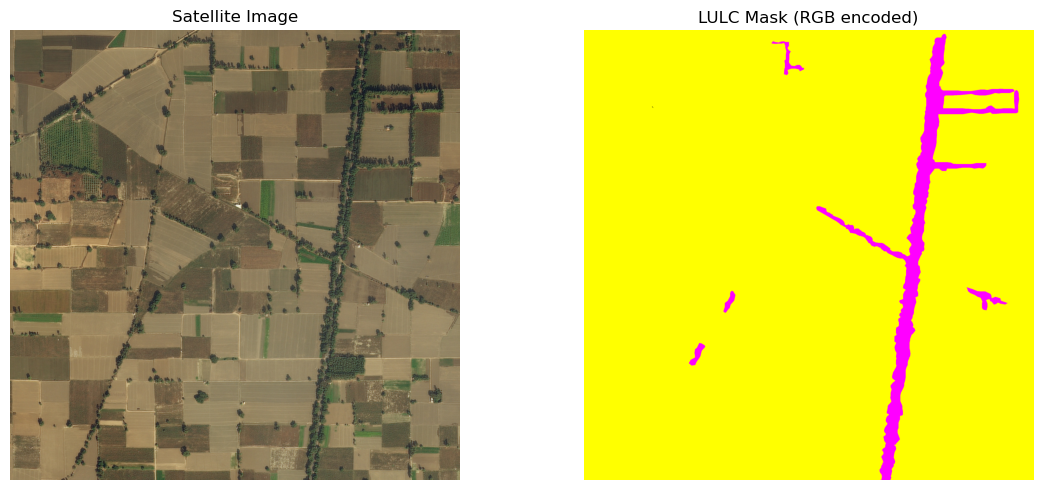

Preview saved.


In [3]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Paths
DATA_DIR  = r"F:\GeoTrack\data\deepglobe\train"
CLASS_CSV = r"F:\GeoTrack\data\deepglobe\class_dict.csv"

# Load class definitions
class_df = pd.read_csv(CLASS_CSV)
print("Classes:")
print(class_df)

# Separate images and masks
all_files = sorted(os.listdir(DATA_DIR))
images = [f for f in all_files if f.endswith("_sat.jpg")]
masks  = [f for f in all_files if f.endswith("_mask.png")]

print(f"\nTrain images : {len(images)}")
print(f"Train masks  : {len(masks)}")

# Peek at one pair
img  = Image.open(os.path.join(DATA_DIR, images[0])).convert("RGB")
mask = Image.open(os.path.join(DATA_DIR, masks[0])).convert("RGB")

print(f"\nImage size : {img.size}")
print(f"Mask size  : {mask.size}")
print(f"Unique mask colors (sample): {np.unique(np.array(mask).reshape(-1,3), axis=0)[:8]}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title("Satellite Image")
axes[0].axis("off")
axes[1].imshow(mask)
axes[1].set_title("LULC Mask (RGB encoded)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(r"F:\GeoTrack\data\sample_preview.png", dpi=150)
plt.show()
print("Preview saved.")

### Block 4: Color Mask → Class Index Converter

RGB mask shape   : (2448, 2448, 3)
Class mask shape : (2448, 2448)
Unique classes   : [1 2 6]
Class names present: ['agriculture_land', 'rangeland', 'unknown']


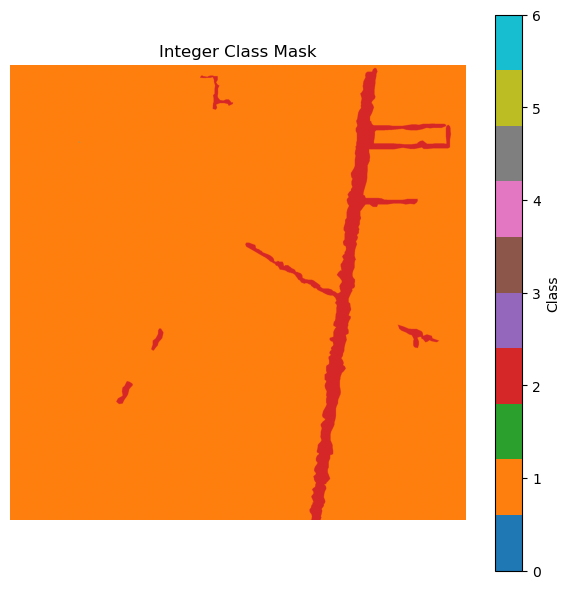

Class mask preview saved.


In [4]:
import numpy as np
from PIL import Image

# Class color map from class_dict.csv
COLOR_TO_CLASS = {
    (0,   255, 255): 0,  # urban_land
    (255, 255,   0): 1,  # agriculture_land
    (255,   0, 255): 2,  # rangeland
    (0,   255,   0): 3,  # forest_land
    (0,     0, 255): 4,  # water
    (255, 255, 255): 5,  # barren_land
    (0,     0,   0): 6,  # unknown
}

CLASS_NAMES = [
    "urban_land",
    "agriculture_land", 
    "rangeland",
    "forest_land",
    "water",
    "barren_land",
    "unknown"
]

NUM_CLASSES = 6  # we ignore unknown (class 6) during training

def rgb_mask_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    """
    Convert RGB encoded mask to integer class index mask.
    Input:  HxWx3 numpy array (RGB)
    Output: HxW numpy array (int class index)
    """
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)
    
    for color, class_idx in COLOR_TO_CLASS.items():
        # Find all pixels matching this color
        match = np.all(mask_rgb == np.array(color), axis=-1)
        class_mask[match] = class_idx
    
    return class_mask

# Test it on first sample
mask_path = os.path.join(DATA_DIR, masks[0])
mask_rgb   = np.array(Image.open(mask_path).convert("RGB"))
class_mask = rgb_mask_to_class(mask_rgb)

print(f"RGB mask shape   : {mask_rgb.shape}")
print(f"Class mask shape : {class_mask.shape}")
print(f"Unique classes   : {np.unique(class_mask)}")
print(f"Class names present: {[CLASS_NAMES[i] for i in np.unique(class_mask) if i < len(CLASS_NAMES)]}")

# Visualize class mask
plt.figure(figsize=(6,6))
plt.imshow(class_mask, cmap="tab10", vmin=0, vmax=6)
plt.colorbar(ticks=range(7), label="Class")
plt.title("Integer Class Mask")
plt.axis("off")
plt.tight_layout()
plt.savefig(r"F:\GeoTrack\data\class_mask_preview.png", dpi=150)
plt.show()
print("Class mask preview saved.")

### Block 5 — Tiling (2448×2448 → 256×256 Patches)
Why We Tile

2448×2448 is too large for CPU training. We cut each image into 256×256 tiles.

Math
Each 2448×2448 image → ~81 tiles
803 images × 81 tiles = ~65,000 patches → too many for CPU
We use 200 images → ~16,000 tiles → manageable

In [5]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Config
TILE_SIZE   = 256
NUM_IMAGES  = 200  # prototype subset
TILES_DIR   = r"F:\GeoTrack\data\tiles"

os.makedirs(os.path.join(TILES_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(TILES_DIR, "masks"),  exist_ok=True)

def tile_image_and_mask(img_path, mask_path, tile_size=256):
    """
    Cut image and mask into non-overlapping tiles.
    Skips tiles where >50% pixels are unknown class (6).
    Returns list of (image_tile, mask_tile) numpy arrays.
    """
    img  = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("RGB"))
    mask = rgb_mask_to_class(mask)

    h, w = img.shape[:2]
    tiles = []

    for y in range(0, h - tile_size + 1, tile_size):
        for x in range(0, w - tile_size + 1, tile_size):
            img_tile  = img[y:y+tile_size,  x:x+tile_size]
            mask_tile = mask[y:y+tile_size, x:x+tile_size]

            # Skip tiles dominated by unknown class
            unknown_ratio = np.sum(mask_tile == 6) / (tile_size * tile_size)
            if unknown_ratio > 0.5:
                continue

            tiles.append((img_tile, mask_tile))

    return tiles

# Process subset
tile_count = 0
subset = images[:NUM_IMAGES]

print(f"Tiling {NUM_IMAGES} images into {TILE_SIZE}x{TILE_SIZE} patches...")

for fname in tqdm(subset):
    img_path  = os.path.join(DATA_DIR, fname)
    mask_fname = fname.replace("_sat.jpg", "_mask.png")
    mask_path  = os.path.join(DATA_DIR, mask_fname)

    if not os.path.exists(mask_path):
        continue

    tiles = tile_image_and_mask(img_path, mask_path, TILE_SIZE)

    for img_tile, mask_tile in tiles:
        Image.fromarray(img_tile).save(
            os.path.join(TILES_DIR, "images", f"tile_{tile_count:05d}.png"))
        Image.fromarray(mask_tile).save(
            os.path.join(TILES_DIR, "masks",  f"tile_{tile_count:05d}.png"))
        tile_count += 1

print(f"\nDone. Total tiles generated : {tile_count}")
print(f"Saved to : {TILES_DIR}")

Tiling 200 images into 256x256 patches...


100%|██████████| 200/200 [14:02<00:00,  4.21s/it]


Done. Total tiles generated : 16191
Saved to : F:\GeoTrack\data\tiles


Mask unique values : [0 5]
Mask min/max       : 0 / 5
Image min/max      : 0 / 233


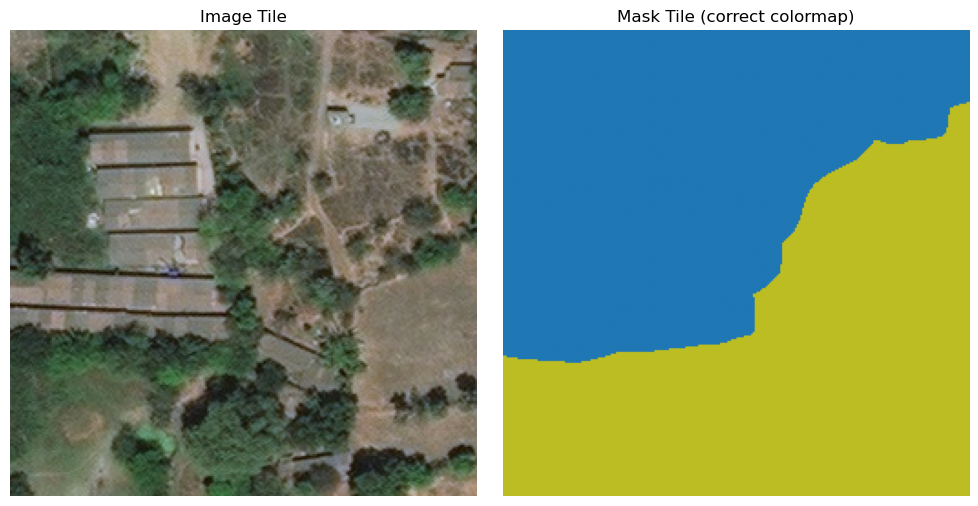

In [9]:
import numpy as np
from PIL import Image

# Check one mask tile
mask_tile = np.array(Image.open(r"F:\GeoTrack\data\tiles\masks\tile_00590.png"))
img_tile  = np.array(Image.open(r"F:\GeoTrack\data\tiles\images\tile_00590.png"))

print(f"Mask unique values : {np.unique(mask_tile)}")
print(f"Mask min/max       : {mask_tile.min()} / {mask_tile.max()}")
print(f"Image min/max      : {img_tile.min()} / {img_tile.max()}")

# Visualize correctly
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_tile)
axes[0].set_title("Image Tile")
axes[0].axis("off")
axes[1].imshow(mask_tile, cmap="tab10", vmin=0, vmax=6)
axes[1].set_title("Mask Tile (correct colormap)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Block 6 — Dataset Class & DataLoader
What This Does
Loads image and mask tiles from disk
Applies augmentations during training (flips, rotations)
Wraps everything in PyTorch Dataset and DataLoader — this is how PyTorch feeds data to the model batch by batch

In [10]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Paths
TILES_IMG_DIR  = r"F:\GeoTrack\data\tiles\images"
TILES_MASK_DIR = r"F:\GeoTrack\data\tiles\masks"

# Get all tile filenames
all_tiles = sorted(os.listdir(TILES_IMG_DIR))
print(f"Total tiles: {len(all_tiles)}")

# Train / Val split
train_tiles, val_tiles = train_test_split(
    all_tiles, 
    test_size=0.2, 
    random_state=42
)
print(f"Train tiles : {len(train_tiles)}")
print(f"Val tiles   : {len(val_tiles)}")

# Augmentations for training
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# No augmentation for validation — just normalize
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Dataset class
class DeepGlobeDataset(Dataset):
    """
    PyTorch Dataset for DeepGlobe tiles.
    __len__  → tells PyTorch how many samples exist
    __getitem__ → loads one image+mask pair by index
    """
    def __init__(self, tile_names, img_dir, mask_dir, transform=None):
        self.tile_names = tile_names
        self.img_dir    = img_dir
        self.mask_dir   = mask_dir
        self.transform  = transform

    def __len__(self):
        return len(self.tile_names)

    def __getitem__(self, idx):
        fname = self.tile_names[idx]

        # Load image as RGB numpy array
        img  = np.array(Image.open(os.path.join(self.img_dir,  fname)).convert("RGB"))
        
        # Load mask as single channel
        mask = np.array(Image.open(os.path.join(self.mask_dir, fname)))

        # Cap unknown class (6) to 5 — treat as barren_land
        mask = np.clip(mask, 0, 5)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"].long()

        return img, mask

# Create datasets
train_dataset = DeepGlobeDataset(train_tiles, TILES_IMG_DIR, TILES_MASK_DIR, train_transform)
val_dataset   = DeepGlobeDataset(val_tiles,   TILES_IMG_DIR, TILES_MASK_DIR, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# Sanity check — load one batch
imgs, masks = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"Batch mask shape  : {masks.shape}")
print(f"Image dtype       : {imgs.dtype}")
print(f"Mask dtype        : {masks.dtype}")
print(f"Mask unique vals  : {masks.unique()}")

Total tiles: 16191
Train tiles : 12952
Val tiles   : 3239

Train batches : 1619
Val batches   : 405

Batch image shape : torch.Size([8, 3, 256, 256])
Batch mask shape  : torch.Size([8, 256, 256])
Image dtype       : torch.float32
Mask dtype        : torch.int64
Mask unique vals  : tensor([0, 1, 2, 3, 4, 5])


### Block 7 — Model Definition
What This Does
Loads U-Net with a pretrained ResNet34 encoder in literally 3 lines. This is why we installed segmentation-models-pytorch.

Why ResNet34
Pretrained on ImageNet — already knows edges, textures, shapes
We only need to teach it LULC-specific patterns
Lightweight enough for CPU training
Why U-Net
Encoder compresses image → extracts features
Decoder expands back → produces pixel-wise predictions
Skip connections preserve spatial detail lost during compression

In [11]:
import segmentation_models_pytorch as smp
import torch

# Define model
model = smp.Unet(
    encoder_name    = "resnet34",      # pretrained feature extractor
    encoder_weights = "imagenet",      # pretrained on ImageNet
    in_channels     = 3,               # RGB input
    classes         = 6,               # 6 LULC classes
    activation      = None             # raw logits — loss function handles activation
)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# Verify with one forward pass
model.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 3, 256, 256)
    dummy_output = model(dummy_input)
    print(f"\nInput shape  : {dummy_input.shape}")
    print(f"Output shape : {dummy_output.shape}")
    print(f"\nOutput shape means: [1 image, 6 class scores, 256x256 pixels]")
    print("Model is working correctly.")

c:\Users\shubh\.conda\envs\dl_env\lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shubh\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Total parameters     : 24,437,094
Trainable parameters : 24,437,094

Input shape  : torch.Size([1, 3, 256, 256])
Output shape : torch.Size([1, 6, 256, 256])

Output shape means: [1 image, 6 class scores, 256x256 pixels]
Model is working correctly.


### Block 8 — Loss Function & Optimizer
What This Does

Defines how the model measures its own mistakes and how it corrects them.

Two Loss Functions Combined

CrossEntropyLoss — penalizes wrong class predictions per pixel

DiceLoss — penalizes poor overlap between predicted and actual segmentation regions. Critical for imbalanced classes like water or barren land which appear rarely.

We combine both because CrossEntropy alone struggles with class imbalance in LULC data.

Optimizer

Adam — standard, works well, no tuning needed for prototype.

In [12]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# Loss functions
ce_loss   = nn.CrossEntropyLoss()
dice_loss = smp.losses.DiceLoss(mode="multiclass", classes=6)

def combined_loss(pred, target):
    """
    Combined loss = CrossEntropy + DiceLoss
    pred   : [B, 6, H, W] raw logits from model
    target : [B, H, W] integer class indices
    """
    return ce_loss(pred, target) + dice_loss(pred, target)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler — reduces LR when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode    = "min", 
    patience= 2, 
    factor  = 0.5,
    verbose = True
)

print("Loss functions : CrossEntropyLoss + DiceLoss")
print("Optimizer      : Adam (lr=1e-4)")
print("Scheduler      : ReduceLROnPlateau (patience=2)")

# Quick sanity check
model.eval()
with torch.no_grad():
    dummy_imgs  = torch.randn(2, 3, 256, 256)
    dummy_masks = torch.zeros(2, 256, 256, dtype=torch.long)
    dummy_preds = model(dummy_imgs)
    loss_val    = combined_loss(dummy_preds, dummy_masks)
    print(f"\nSanity check loss : {loss_val.item():.4f}")
    print("Loss function working correctly.")

c:\Users\shubh\.conda\envs\dl_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Loss functions : CrossEntropyLoss + DiceLoss
Optimizer      : Adam (lr=1e-4)
Scheduler      : ReduceLROnPlateau (patience=2)

Sanity check loss : 2.3766
Loss function working correctly.


### Block 9 — Training Loop
What This Does

Trains the model for multiple epochs. Each epoch:

Train phase — model sees training tiles, makes predictions, calculates loss, updates weights
Val phase — model sees validation tiles, we measure IoU (no weight updates)
What is IoU

Intersection over Union — the metric that goes in your PPT.

IoU = (pixels correctly predicted as class X) / 
      (all pixels predicted OR actually class X)

Score of 1.0 = perfect. Score of 0.0 = completely wrong. Anything above 0.45 on DeepGlobe with a prototype is respectable.

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

DEVICE = torch.device("cpu")
EPOCHS = 5  # start with 2 to verify, then increase to 5
NUM_CLASSES = 6

model = model.to(DEVICE)

def compute_iou(preds, masks, num_classes=6):
    """
    Compute mean IoU across all classes.
    preds : [B, 6, H, W] logits
    masks : [B, H, W] integer class indices
    """
    pred_classes = torch.argmax(preds, dim=1)  # [B, H, W]
    iou_list = []

    for cls in range(num_classes):
        pred_cls   = (pred_classes == cls)
        target_cls = (masks == cls)

        intersection = (pred_cls & target_cls).sum().float()
        union        = (pred_cls | target_cls).sum().float()

        if union == 0:
            continue  # skip classes not present in batch

        iou_list.append((intersection / union).item())

    return np.mean(iou_list) if iou_list else 0.0

# Training history for plotting
history = {"train_loss": [], "val_loss": [], "val_iou": []}

print(f"Training on : {DEVICE}")
print(f"Epochs      : {EPOCHS}")
print(f"Train batches per epoch : {len(train_loader)}")
print("-" * 50)

for epoch in range(EPOCHS):
    # ---- TRAIN PHASE ----
    model.train()
    train_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- VAL PHASE ----
    model.eval()
    val_loss = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  "):
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)
            preds = model(imgs)

            val_loss += combined_loss(preds, masks).item()
            val_iou  += compute_iou(preds, masks)

    val_loss /= len(val_loader)
    val_iou  /= len(val_loader)

    # Scheduler step
    scheduler.step(val_loss)

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print(f"  Val mIoU   : {val_iou:.4f}")
    print("-" * 50)

# Save model checkpoint
torch.save(model.state_dict(), r"F:\GeoTrack\model\unet_resnet34_checkpoint.pth")
print("Model saved to F:\\GeoTrack\\model\\unet_resnet34_checkpoint.pth")

Training on : cpu
Epochs      : 2
Train batches per epoch : 1619
--------------------------------------------------


Epoch 1/2 [Train]:   2%|▏         | 25/1619 [02:49<3:00:08,  6.78s/it]


KeyboardInterrupt: 